In [1]:
import pandas as pd

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition 2.csv')

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
df.shape    

(1470, 35)

In [3]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
# Standardize department labels (safety net even if already clean)
df['Department'] = df['Department'].str.strip().str.title()

# Encode Attrition and OverTime as 0/1 flags
df['Attrition_Flag'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['OverTime_Flag'] = df['OverTime'].map({'Yes': 1, 'No': 0})

# Create tenure bands
df['TenureBand'] = pd.cut(df['YearsAtCompany'], bins=[0,2,5,10,40],
                           labels=['0-2 yrs','3-5 yrs','6-10 yrs','10+ yrs'])

# Create salary brackets
df['SalaryBracket'] = pd.qcut(df['MonthlyIncome'], q=4,
                               labels=['Low','Mid-Low','Mid-High','High'])

df[['Department','Attrition_Flag','OverTime_Flag','TenureBand','SalaryBracket']].head()

,Department,Attrition_Flag,OverTime_Flag,TenureBand,SalaryBracket
0,Sales,1,1,6-10 yrs,Mid-High
1,Research & Development,0,0,6-10 yrs,Mid-High
2,Research & Development,1,1,NaN,Low
3,Research & Development,0,1,6-10 yrs,Low
4,Research & Development,0,0,0-2 yrs,Mid-Low


In [7]:
df.to_csv("hr_cleaned.csv", index=False)

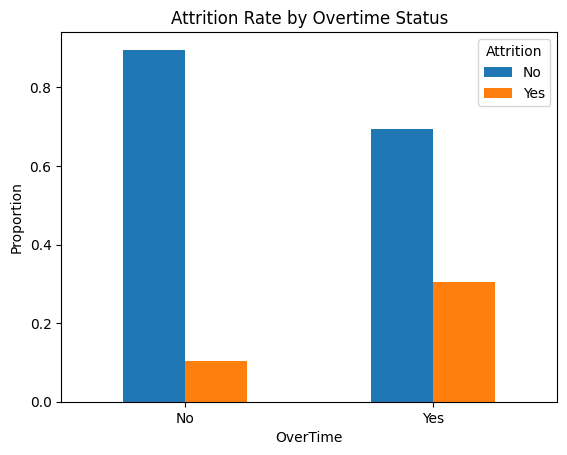

In [8]:
import matplotlib.pyplot as plt

pd.crosstab(df['OverTime'], df['Attrition'], normalize='index').plot(kind='bar')
plt.title('Attrition Rate by Overtime Status')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.show()

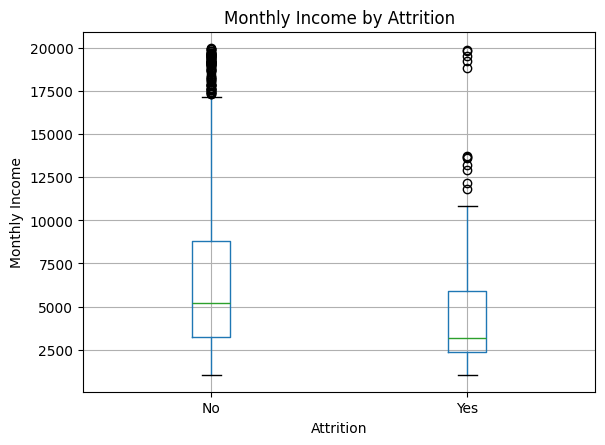

In [9]:
df.boxplot(column='MonthlyIncome', by='Attrition')
plt.title('Monthly Income by Attrition')
plt.suptitle('')  # removes the default pandas subtitle
plt.ylabel('Monthly Income')
plt.show()

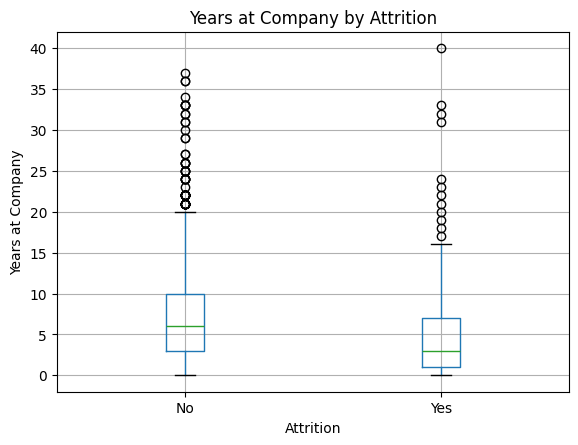

In [10]:
df.boxplot(column='YearsAtCompany', by='Attrition')
plt.title('Years at Company by Attrition')
plt.suptitle('')
plt.ylabel('Years at Company')
plt.show()

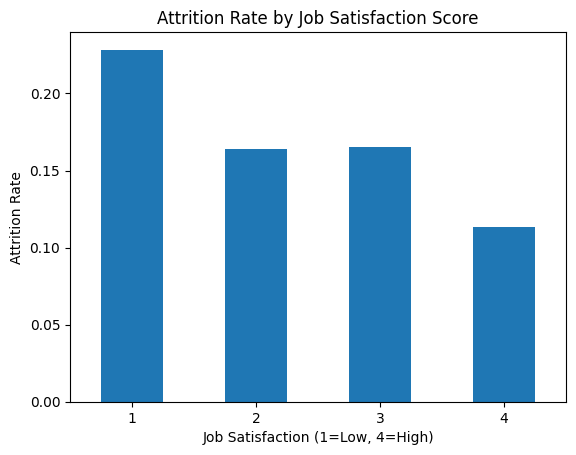

In [11]:
df.groupby('JobSatisfaction')['Attrition_Flag'].mean().plot(kind='bar')
plt.title('Attrition Rate by Job Satisfaction Score')
plt.ylabel('Attrition Rate')
plt.xlabel('Job Satisfaction (1=Low, 4=High)')
plt.xticks(rotation=0)
plt.show()